# Make figure 4

Visualize the regions we computed WMT budgets for

In [1]:
import xarray as xr
import numpy as np
import dask
import pandas as pd
import xwmb
import xwmt
import xgcm
import warnings
warnings.filterwarnings('ignore')
import math

import regionate
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 22}) 

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

import cftime
from datetime import datetime
print(xwmb.__version__, xwmt.__version__, xgcm.__version__)
import cmocean
from matplotlib.patches import Rectangle
import matplotlib.cm as cm

0.6.0 0.2.0 0.9.0


In [5]:
mt_path = "/pub/mariant3/WarmWaterMasses/data/"

ocetrac_labels = xr.open_dataset(f"{mt_path}/ocetrac-v9-blobs-tos-t1-r1-msq0-01860315-01891214-region.nc", chunks={'time':1})
labels = ocetrac_labels.blobs.load()

wmt = xr.open_dataset(
    f"{mt_path}0186-0189_wmt-daily.nc").sel(
    time=slice("0186","0189")
)

budgets = xr.open_dataset(
    f"{mt_path}yearly-mhw-wmt-budgets-7d-rolling-mask_0186-0189.nc"
)

# budgets_sum = budgets.sum("mhw").load()

In [6]:
model_data_path = "/dfs9/hfdrake_hpc/datasets/CM4_MHW_blobs/"
ds = xr.open_dataset(
    f"{model_data_path}/data/ocean_daily_cmip.01860101-01901231.tos.nc",
    chunks={'time':100}
).sel(time=slice("0186","0189")).sel(
    xh=slice(labels.xh.min(), labels.xh.max()), 
    yh=slice(labels.yh.min(), labels.yh.max())
)

# region_tos = ds['tos']
# #ds = xr.open_mfdataset(f"{model_data_path}/data/ocean_daily_cmip*.nc", chunks={'time':100}).sel(xh=slice(-130, -70), yh=slice(8, 38))
#region_tos = ds['tos']

static = xr.open_dataset(
    f"{model_data_path}data/WMT_monthly/ocean_month_rho2.static.nc"
)
ds = xr.merge([ds, static], join="inner")

In [9]:
ids = np.unique(labels.sel(time=slice("0186","0186")))#.sel(xh = slice(-98, -75), yh=slice(18, 32)).sel(time=slice("0186-07","0186-08")))
ids = np.array([id for id in ids if ~np.isnan(id)])

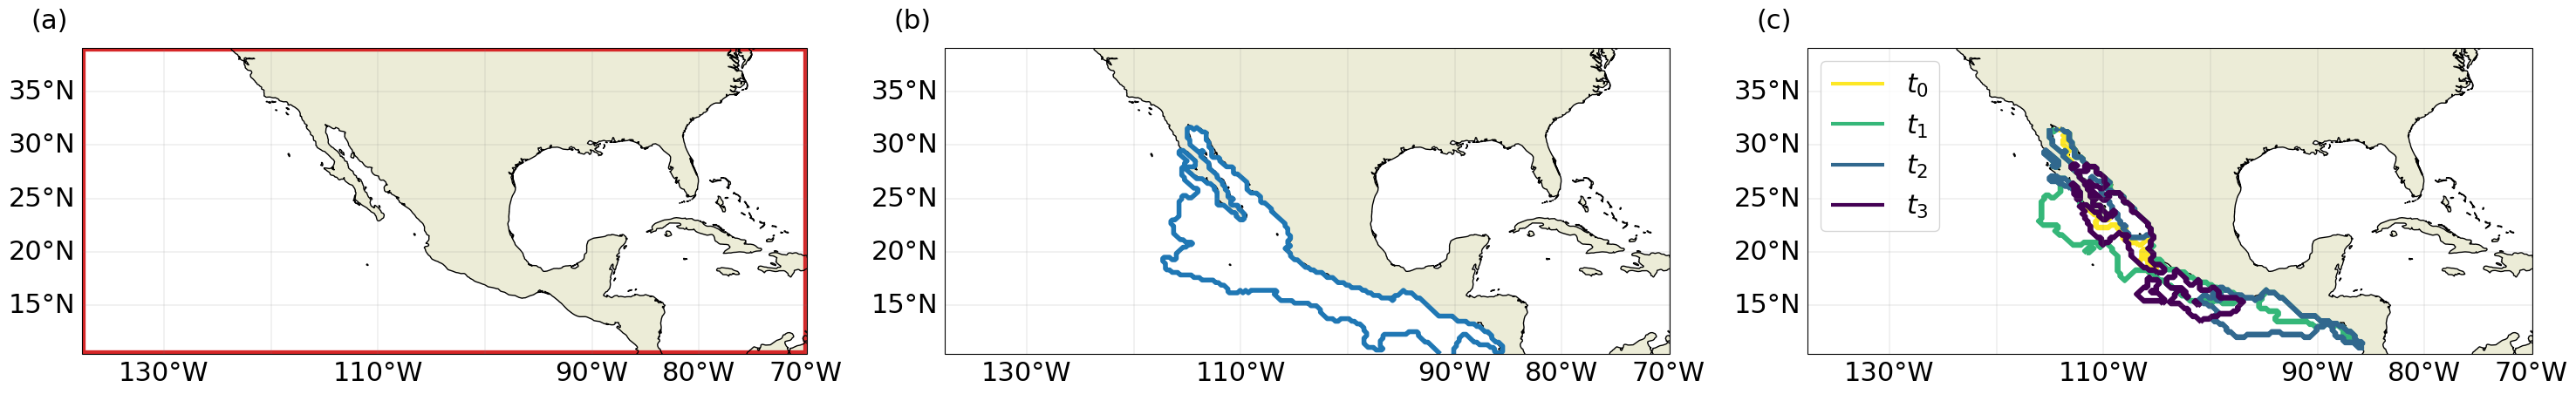

In [10]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.patches import Rectangle


fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(30, 10), 
                                   subplot_kw={'projection': ccrs.PlateCarree()})

ax3.coastlines()
ax3.add_feature(cfeature.LAND, facecolor='#ececd7')
ax3.set_xlim([labels.xh.min(), labels.xh.max()])
ax3.set_ylim([labels.yh.min(), labels.yh.max()])

time_indices = [50, 80, 100, 130]
cmap = cm.get_cmap('viridis_r')
colors = [cmap(i / (len(time_indices) - 1)) for i in range(len(time_indices))]

contour_objects = []
contour_labels = []

for i, time_idx in enumerate(time_indices):
    event = labels.where(labels==559, drop=True).isel(time=time_idx)
    event1 = event == event
    cs = event1.plot.contour(ax=ax3, colors=[colors[i]], linewidths=3, 
                            add_labels=False, add_colorbar=False)
    
    contour_objects.append(cs.collections[0])
    contour_labels.append(rf'$t_{i}$')

ax3.legend(contour_objects, contour_labels, loc='upper left')#,fontsize=25)

gl3 = ax3.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.5, linestyle='-')
gl3.top_labels = False
gl3.right_labels = False
# ax2.set_title('Event 559 - Multiple Times')
ax3.text(-0.07, 1.13, '(c)', transform=ax3.transAxes, va='top')


ax2.coastlines()
ax2.add_feature(cfeature.LAND, facecolor='#ececd7')
ax2.set_xlim([labels.xh.min(), labels.xh.max()])
ax2.set_ylim([labels.yh.min(), labels.yh.max()])
event2 = (labels==559).any("time")
event2.plot.contour(ax=ax2, levels=[0.5], colors='C0', linewidths=4, linestyles='-')
gl2 = ax2.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.5, linestyle='-')
gl2.top_labels = False
gl2.right_labels = False
# ax1.set_title('Event 559 - Total Extent')
ax2.text(-0.07, 1.13, '(b)', transform=ax2.transAxes, va='top')

ax1.coastlines()
ax1.add_feature(cfeature.LAND, facecolor='#ececd7')

ax1.set_xlim([labels.xh.min(), labels.xh.max()])
ax1.set_ylim([labels.yh.min(), labels.yh.max()])

rect = Rectangle((labels.xh.min(), labels.yh.min()), 
                 labels.xh.max() - labels.xh.min(), 
                 labels.yh.max() - labels.yh.min(),
                 linewidth=6, edgecolor='C3', facecolor='none',
                 transform=ccrs.PlateCarree())
ax1.add_patch(rect)

gl1 = ax1.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.5, linestyle='-')
gl1.top_labels = False
gl1.right_labels = False
ax1.text(-0.07, 1.13, '(a)', transform=ax1.transAxes, va='top')
# ax1.text(0.008, 1.08, '(a)', transform=ax1.transAxes, va='top', fontsize=14)

plt.tight_layout()
# plt.savefig(f"/pub/mariant3/WarmWaterMasses/figures/budget-masks.png", dpi=350, bbox_inches="tight")

plt.show()

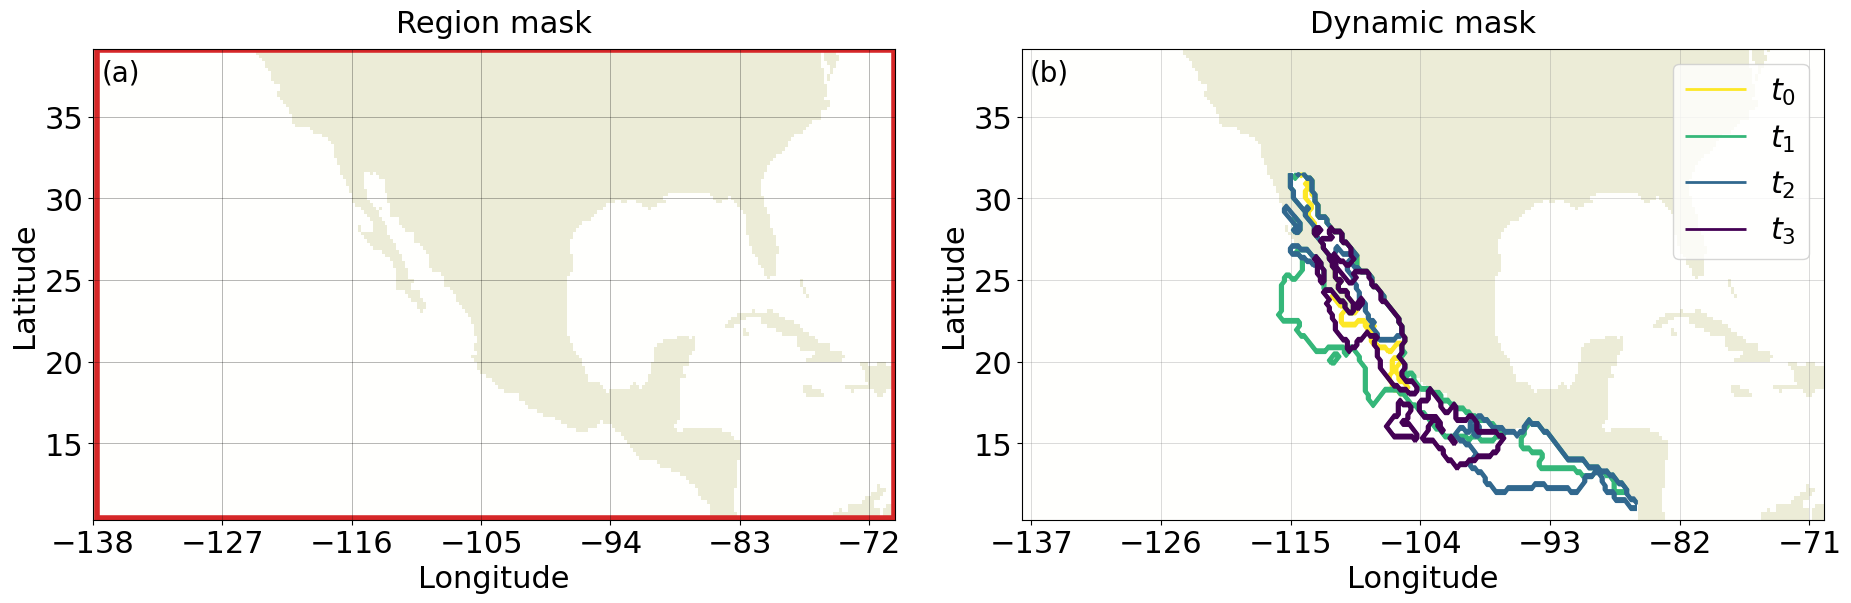

In [15]:
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(19, 6.5)
)

cmap = cmocean.cm.gray

ax1.set_facecolor('#ececd7')

ds.deptho.plot(
    cmap=cmap,
    ax=ax1,
    add_colorbar=False,
    vmin=0,
    vmax=0
)

ax1.set_title("Region mask", fontsize=22, pad=12)
# ax1.set_title("", fontsize=22, fontweight='bold', pad=12)

ax1.set_xlabel("Longitude")
ax1.set_ylabel("Latitude")

ax1.set_xticks(
    np.int32(np.arange(ds.deptho.xh.min()-1,
                       ds.deptho.xh.max(), 11))
)

ax1.grid(True, linewidth=0.4, color='k', alpha=0.5)

rect = Rectangle(
    (labels.xh.min(), labels.yh.min()),
    labels.xh.max() - labels.xh.min(),
    labels.yh.max() - labels.yh.min(),
    linewidth=4,
    edgecolor='C3',
    facecolor='none'
)

ax1.add_patch(rect)

ax1.text(
    0.01, 0.98,
    '(a)',
    transform=ax1.transAxes,
    va='top',
    fontsize=20
)

ax2.set_facecolor('#ececd7')

ds.deptho.plot(
    cmap=cmap,
    ax=ax2,
    add_colorbar=False,
    vmin=0,
    vmax=0
)

# ax2.set_title("Event mask for WMT Budget", fontsize=22, fontweight='bold', pad=12)
ax2.set_title("Dynamic mask", fontsize=22, pad=12)

time_indices = [50, 80, 100, 130]

cmap_contour = plt.cm.get_cmap('viridis_r')
colors = [cmap_contour(i / (len(time_indices) - 1))
          for i in range(len(time_indices))]

contour_objects = []
contour_labels = []

for i, time_idx in enumerate(time_indices):
    event = labels.where(labels == 559, drop=True).isel(time=time_idx)
    event_mask = event == event

    cs = event_mask.plot.contour(
        ax=ax2,
        colors=[colors[i]],
        linewidths=2,
        add_labels=False,
        add_colorbar=False
    )

    contour_objects.append(cs.collections[0])
    contour_labels.append(rf'$t_{i}$')

ax2.legend(contour_objects, contour_labels, loc='upper right')

ax2.set_xlabel("Longitude")
ax2.set_ylabel("Latitude")

ax2.set_xticks(
    np.int32(np.arange(ds.deptho.xh.min(),
                       ds.deptho.xh.max(), 11))
)

ax2.grid(True, linewidth=0.4, color='gray', alpha=0.5)

ax2.text(
    0.01, 0.98,
    '(b)',
    transform=ax2.transAxes,
    va='top',
    fontsize=20
)

plt.tight_layout()

# plt.savefig(f"../figures/region_paper.png", dpi=400, bbox_inches="tight")
plt.show()

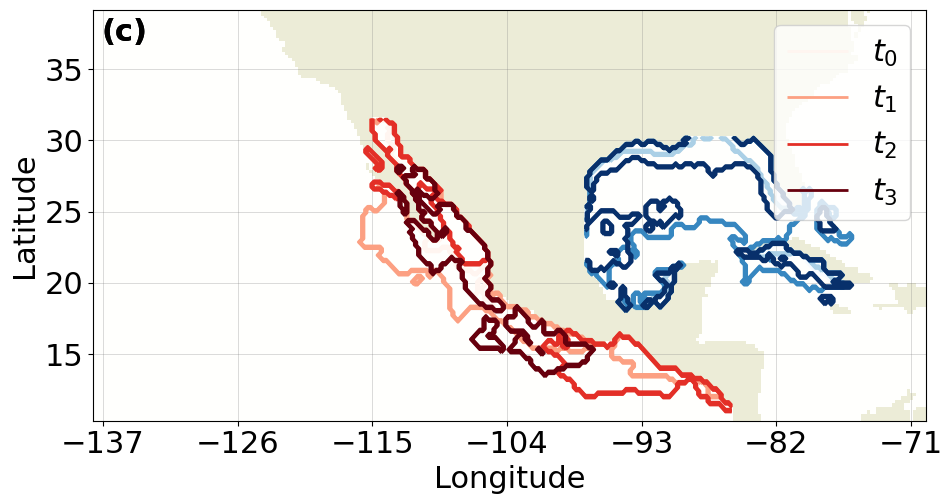

In [16]:
fig = plt.figure(figsize=(10, 5.5))
# plt.subplot(1,3,3)
ax2 = plt.gca() 
ax2.set_facecolor('#ececd7')  
ds.deptho.plot(cmap=cmap, ax=ax2, add_colorbar=False, vmin=0,vmax=0)

time_indices = [50, 80, 100, 120]
cmap_contour = plt.cm.get_cmap('Blues')
colors = [cmap_contour(i / (len(time_indices) - 1)) for i in range(len(time_indices))]
contour_objects = []
contour_labels = []

for i, time_idx in enumerate(time_indices):
    event = labels.where(labels==373, drop=True).isel(time=time_idx)
    event1 = event == event
    cs = event1.plot.contour(ax=ax2, colors=[colors[i]], linewidths=2, 
                            add_labels=False, add_colorbar=False)
    
    contour_objects.append(cs.collections[0])
    contour_labels.append(rf'$t_{i}$')

ax2.legend(contour_objects, contour_labels, loc='upper left')

ax2.set_xlabel("Longitude")
ax2.set_ylabel("Latitude")
ax2.set_xticks(np.int32((np.arange(ds.deptho.xh.min(),ds.deptho.xh.max(),11))))
ax2.grid(True, linewidth=0.4, color='gray', alpha=0.5, linestyle='-')
plt.title("")

# ax2.legend(contour_objects, contour_labels, loc='upper left')

ax2.text(0.01, 0.98, '(c)', transform=ax2.transAxes, va='top', fontweight='bold')

# plt.subplot(1,3,3)
ax2 = plt.gca() 
ax2.set_facecolor('#ececd7')  
ds.deptho.plot(cmap=cmap, ax=ax2, add_colorbar=False, vmin=0,vmax=0)


time_indices = [50, 80, 100, 130]
cmap_contour = plt.cm.get_cmap('Reds')
colors = [cmap_contour(i / (len(time_indices) - 1)) for i in range(len(time_indices))]
contour_objects = []
contour_labels = []

for i, time_idx in enumerate(time_indices):
    event = labels.where(labels==559, drop=True).isel(time=time_idx)
    event1 = event == event
    cs = event1.plot.contour(ax=ax2, colors=[colors[i]], linewidths=2, 
                            add_labels=False, add_colorbar=False)
    
    contour_objects.append(cs.collections[0])
    contour_labels.append(rf'$t_{i}$')

ax2.legend(contour_objects, contour_labels, loc='upper right')


ax2.set_xlabel("Longitude")
ax2.set_ylabel("Latitude")
ax2.set_xticks(np.int32((np.arange(ds.deptho.xh.min(),ds.deptho.xh.max(),11))))
ax2.grid(True, linewidth=0.4, color='gray', alpha=0.5, linestyle='-')
plt.title("")

ax2.text(0.01, 0.98, '(c)', transform=ax2.transAxes, va='top', fontweight='bold')


plt.tight_layout()
# plt.savefig(f"../figures/budget-masks1.png", dpi=350, bbox_inches="tight")

plt.show()